In [1]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [2]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


TensorFlow version: 2.19.0
Num GPUs Available: 0


In [4]:
import pandas as pd
import numpy as np
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf

# Paths
metadata_path = "HAM10000_metadata.csv"  # change if different
image_folder = "HAM10000_images_part_1"         # folder where images are stored

# Load metadata
df = pd.read_csv(metadata_path)

# Encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['dx'])

# Image preprocessing
IMG_SIZE = 64  # small size to keep training fast
images = []
labels = []

for index, row in df.iterrows():
    img_path = os.path.join(image_folder, row['image_id'] + '.jpg')
    if os.path.exists(img_path):
        img = cv2.imread(img_path)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        images.append(img)
        labels.append(row['label'])

# Convert to NumPy arrays
X = np.array(images) / 255.0  # normalize pixel values
y = np.array(labels)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data shape:", X_train.shape, y_train.shape)


Data shape: (8012, 64, 64, 3) (8012,)


In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# 1. Encode the labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# 2. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

# 3. Build CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(y_categorical.shape[1], activation='softmax')  # Number of classes
])

# 4. Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 5. Train the model
history = model.fit(X_train, y_train, validation_split=0.1, epochs=10, batch_size=32)

# 6. Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")


C:\Users\Admin\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 25s 96ms/step - accuracy: 0.6466 - loss: 1.1910 - val_accuracy: 0.6958 - val_loss: 0.9067
Epoch 2/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 25s 109ms/step - accuracy: 0.6722 - loss: 0.9593 - val_accuracy: 0.6895 - val_loss: 0.8312
Epoch 3/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 41s 107ms/step - accuracy: 0.6714 - loss: 0.9301 - val_accuracy: 0.7020 - val_loss: 0.8362
Epoch 4/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 23s 101ms/step - accuracy: 0.6722 - loss: 0.8843 - val_accuracy: 0.7032 - val_loss: 0.7796
Epoch 5/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 41s 101ms/step - accuracy: 0.6889 - loss: 0.8182 - val_accuracy: 0.7282 - val_loss: 0.7354
Epoch 6/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 42s 103ms/step - accuracy: 0.7049 - loss: 0.8009 - val_accuracy: 0.7469 - val_loss: 0.7340
Epoch 7/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 24s 104ms/step - accuracy: 0.7127 - loss: 0.7744 - val_accuracy: 0.7444 - val_loss: 0.6946
Epoch 8/10
226/226 ━━━━━━━━━━━━━━━━━━━━ 38s 90ms/step - accuracy: 0.7155 - loss: 0.7

In [8]:
model.save("skin_cancer_cnn_model.keras")


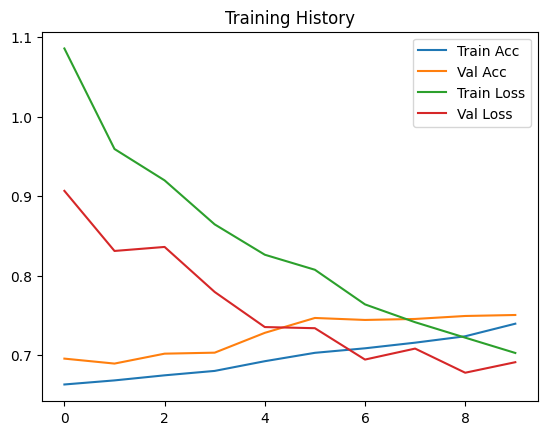

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Training History")
plt.show()


In [11]:
import pickle

# After encoding labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Save the label encoder
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)
